# Final Task: Loan Prediction Model
---
## Prediksi Performa Kredit Peminjam (Good vs Bad Loan)

**Dataset:** Loan Data 2007-2014 (LendingClub)
**Objective:** Membangun model Machine Learning untuk memprediksi apakah peminjam akan memiliki performa kredit yang baik (GOOD) atau buruk (BAD).
**Algoritma:** Logistic Regression & Random Forest Classifier

---
### Alur Pengerjaan:
1. **Data Understanding** - Memahami struktur dan karakteristik data
2. **Exploratory Data Analysis (EDA)** - Visualisasi dan analisis pola data
3. **Data Preparation** - Pembersihan, encoding, dan scaling data
4. **Data Modelling** - Pelatihan model dengan Logistic Regression & Random Forest
5. **Evaluation** - Evaluasi kinerja model

## 1. Import Libraries
Mengimpor semua library yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pemodelan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengubah Tema Warna Penampilan Seluruh Chart
sns.set_theme(style="whitegrid", palette='tab10', context="notebook", font_scale=1.05)
plt.rcParams['figure.facecolor'] = '#fafafa'
plt.rcParams['axes.facecolor'] = '#ffffff'

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


## 2. Data Understanding
### 2.1 Memuat Dataset
Memuat dataset loan dari file CSV dan melakukan pemeriksaan awal terhadap struktur data.

In [2]:
df = pd.read_csv('loan_data_2007_2014.csv', low_memory=False)
print(f"Ukuran Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"\n5 Baris Pertama:")
df.head()

Ukuran Dataset: 466,285 baris x 75 kolom

5 Baris Pertama:


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Informasi Dataset
Melihat tipe data dan jumlah nilai non-null untuk setiap kolom.

In [3]:
print("Informasi Dataset:")
print(f"Total baris: {df.shape[0]:,}")
print(f"Total kolom: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*60)
df.info()

Informasi Dataset:
Total baris: 466,285
Total kolom: 75

Memory usage: 779.95 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697

### 2.3 Statistik Deskriptif
Melihat ringkasan statistik untuk kolom-kolom numerik.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,466285.0,2.331420e+05,1.346050e+05,0.00,1.165710e+05,2.331420e+05,3.497130e+05,4.662840e+05
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01


### 2.4 Pemeriksaan Missing Values
Mengidentifikasi kolom-kolom yang memiliki nilai kosong (missing values).

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Jumlah kolom dengan missing values: {len(missing_df)} dari {df.shape[1]} kolom\n")
print(missing_df.to_string())

Jumlah kolom dengan missing values: 40 dari 75 kolom

                             Missing Count  Missing %
dti_joint                           466285     100.00
annual_inc_joint                    466285     100.00
total_cu_tl                         466285     100.00
inq_fi                              466285     100.00
all_util                            466285     100.00
max_bal_bc                          466285     100.00
open_rv_24m                         466285     100.00
open_rv_12m                         466285     100.00
il_util                             466285     100.00
total_bal_il                        466285     100.00
mths_since_rcnt_il                  466285     100.00
open_il_24m                         466285     100.00
open_il_12m                         466285     100.00
open_il_6m                          466285     100.00
open_acc_6m                         466285     100.00
verification_status_joint           466285     100.00
inq_last_12m                

### 2.5 Distribusi Target Variable (loan_status)
Melihat distribusi nilai pada kolom `loan_status` yang akan digunakan sebagai dasar pembuatan label target.

Distribusi Loan Status:

  Current                                                 ->  224,226 (48.09%)
  Fully Paid                                              ->  184,739 (39.62%)
  Charged Off                                             ->   42,475 (9.11%)
  Late (31-120 days)                                      ->    6,900 (1.48%)
  In Grace Period                                         ->    3,146 (0.67%)
  Does not meet the credit policy. Status:Fully Paid      ->    1,988 (0.43%)
  Late (16-30 days)                                       ->    1,218 (0.26%)
  Default                                                 ->      832 (0.18%)
  Does not meet the credit policy. Status:Charged Off     ->      761 (0.16%)


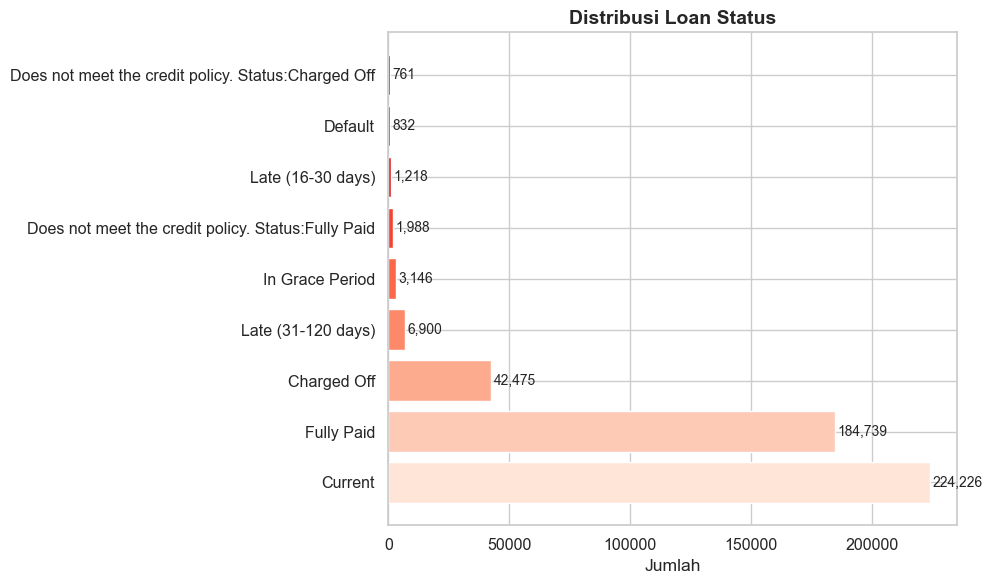

In [6]:
print("Distribusi Loan Status:\n")
status_counts = df['loan_status'].value_counts()
for status, count in status_counts.items():
    pct = count / len(df) * 100
    print(f"  {status:55s} -> {count:>8,} ({pct:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Reds", len(status_counts))
bars = ax.barh(status_counts.index, status_counts.values, color=colors)
ax.set_xlabel('Jumlah')
ax.set_title('Distribusi Loan Status', fontsize=14, fontweight='bold')
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Pembuatan Label Target (Good vs Bad Loan)
### Definisi Label:
- **GOOD (1):** Peminjam dengan performa kredit baik -> `Fully Paid`, `Current`, `Does not meet the credit policy. Status:Fully Paid`
- **BAD (0):** Peminjam dengan performa kredit buruk -> `Charged Off`, `Default`, `Late (31-120 days)`, `Late (16-30 days)`, `In Grace Period`, `Does not meet the credit policy. Status:Charged Off`

Penentuan ini berdasarkan sejarah pembayaran kredit peminjam.

Distribusi Label Target:

  GOOD (1):  410,953 (88.13%)
  BAD  (0):   55,332 (11.87%)


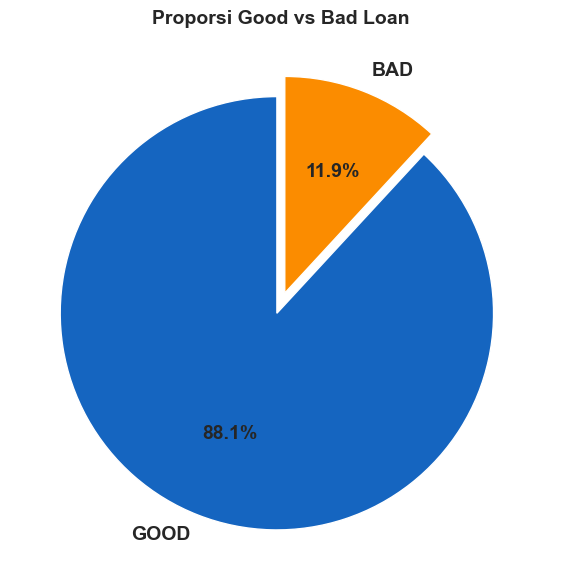

In [7]:
good_status = ['Fully Paid', 'Current', 'Does not meet the credit policy. Status:Fully Paid']
bad_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
              'In Grace Period', 'Does not meet the credit policy. Status:Charged Off']

df['loan_label'] = df['loan_status'].apply(lambda x: 1 if x in good_status else 0)

print("Distribusi Label Target:\n")
label_counts = df['loan_label'].value_counts()
print(f"  GOOD (1): {label_counts[1]:>8,} ({label_counts[1]/len(df)*100:.2f}%)")
print(f"  BAD  (0): {label_counts[0]:>8,} ({label_counts[0]/len(df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
colors_pie = ['#1565C0', '#FB8C00']
ax.pie(label_counts.values, labels=['GOOD', 'BAD'], autopct='%1.1f%%',
       colors=colors_pie, startangle=90, explode=(0.05, 0.05),
       textprops={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title('Proporsi Good vs Bad Loan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)
### 4.1 Analisis Univariat - Distribusi Variabel Numerik
Menganalisis distribusi beberapa variabel numerik penting dalam dataset.

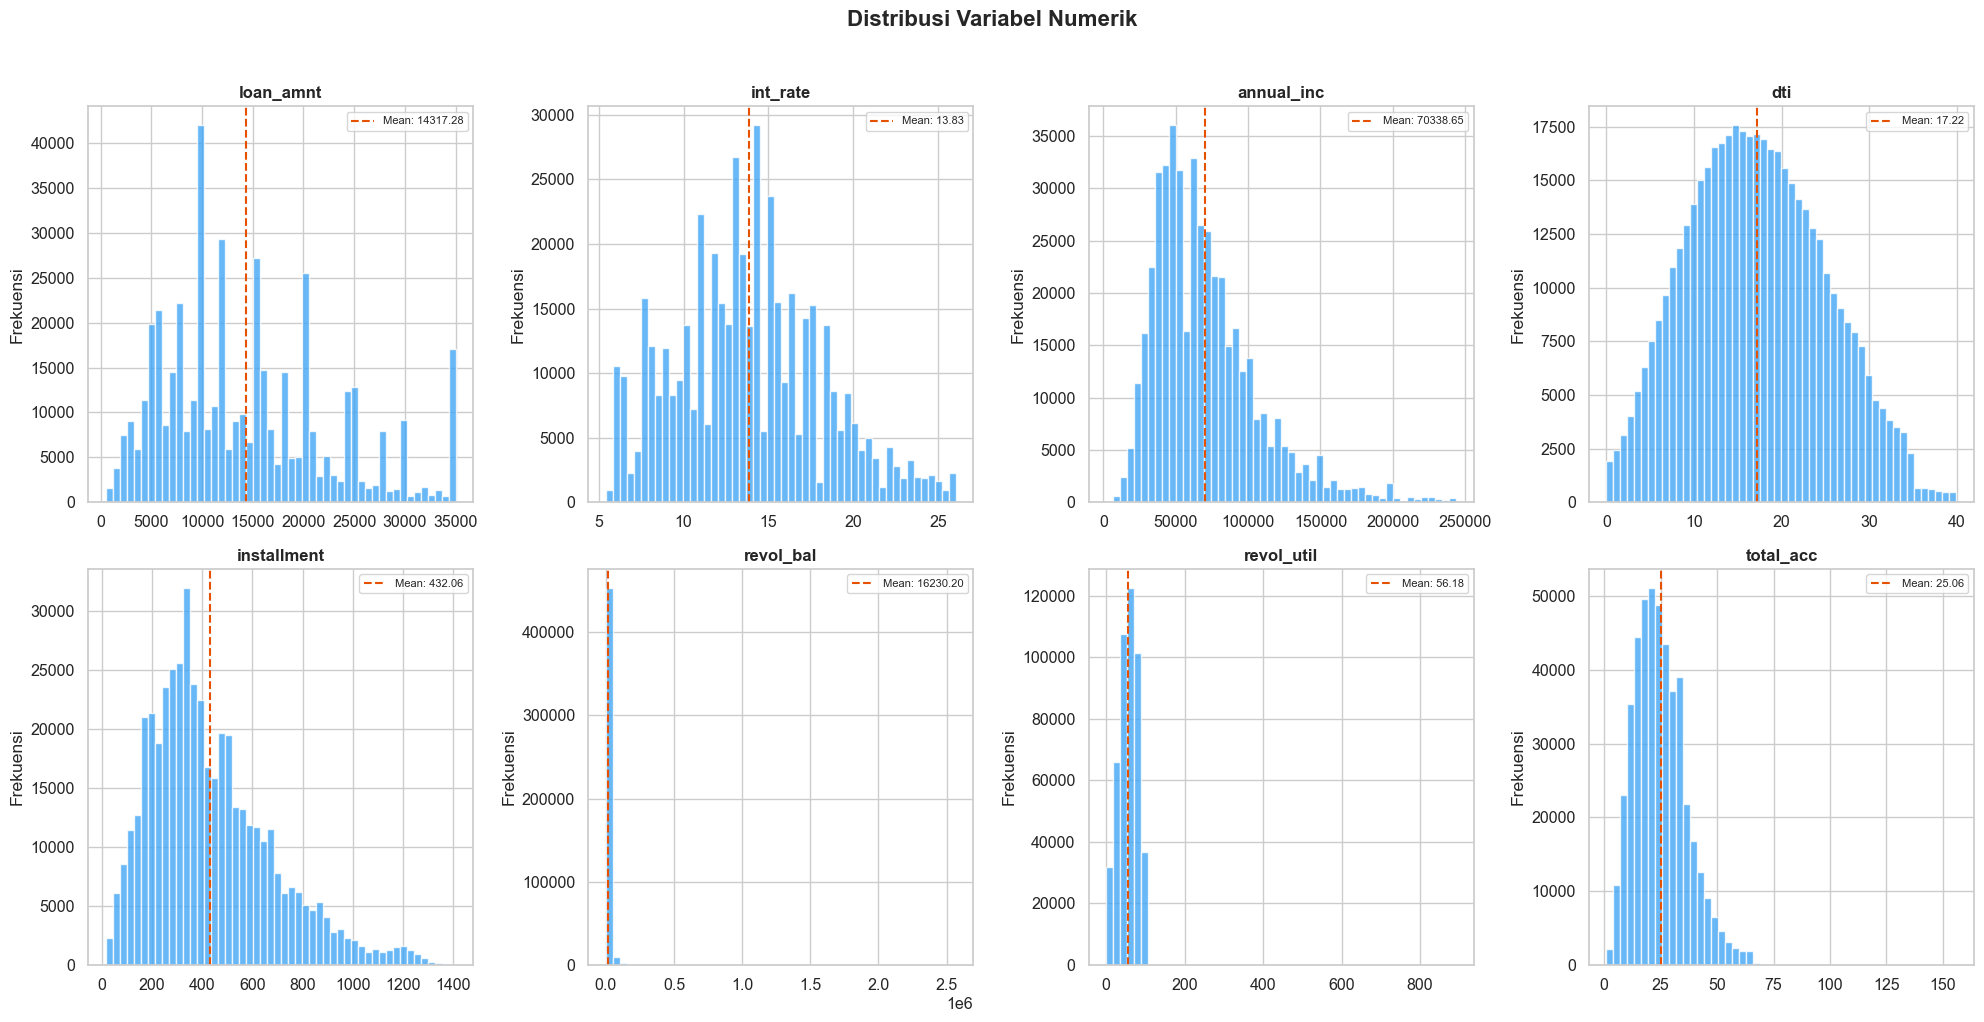

In [8]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_bal', 'revol_util', 'total_acc']
available_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(available_cols):
    data = df[col].dropna()
    if col == 'annual_inc':
        data = data[data < data.quantile(0.99)]
    axes[i].hist(data, bins=50, color='#42A5F5', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(data.mean(), color='#E65100', linestyle='--', label=f'Mean: {data.mean():.2f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribusi Variabel Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Analisis Bivariat - Hubungan Variabel dengan Label Target
Melihat hubungan antara beberapa variabel penting dengan status pinjaman (Good/Bad).

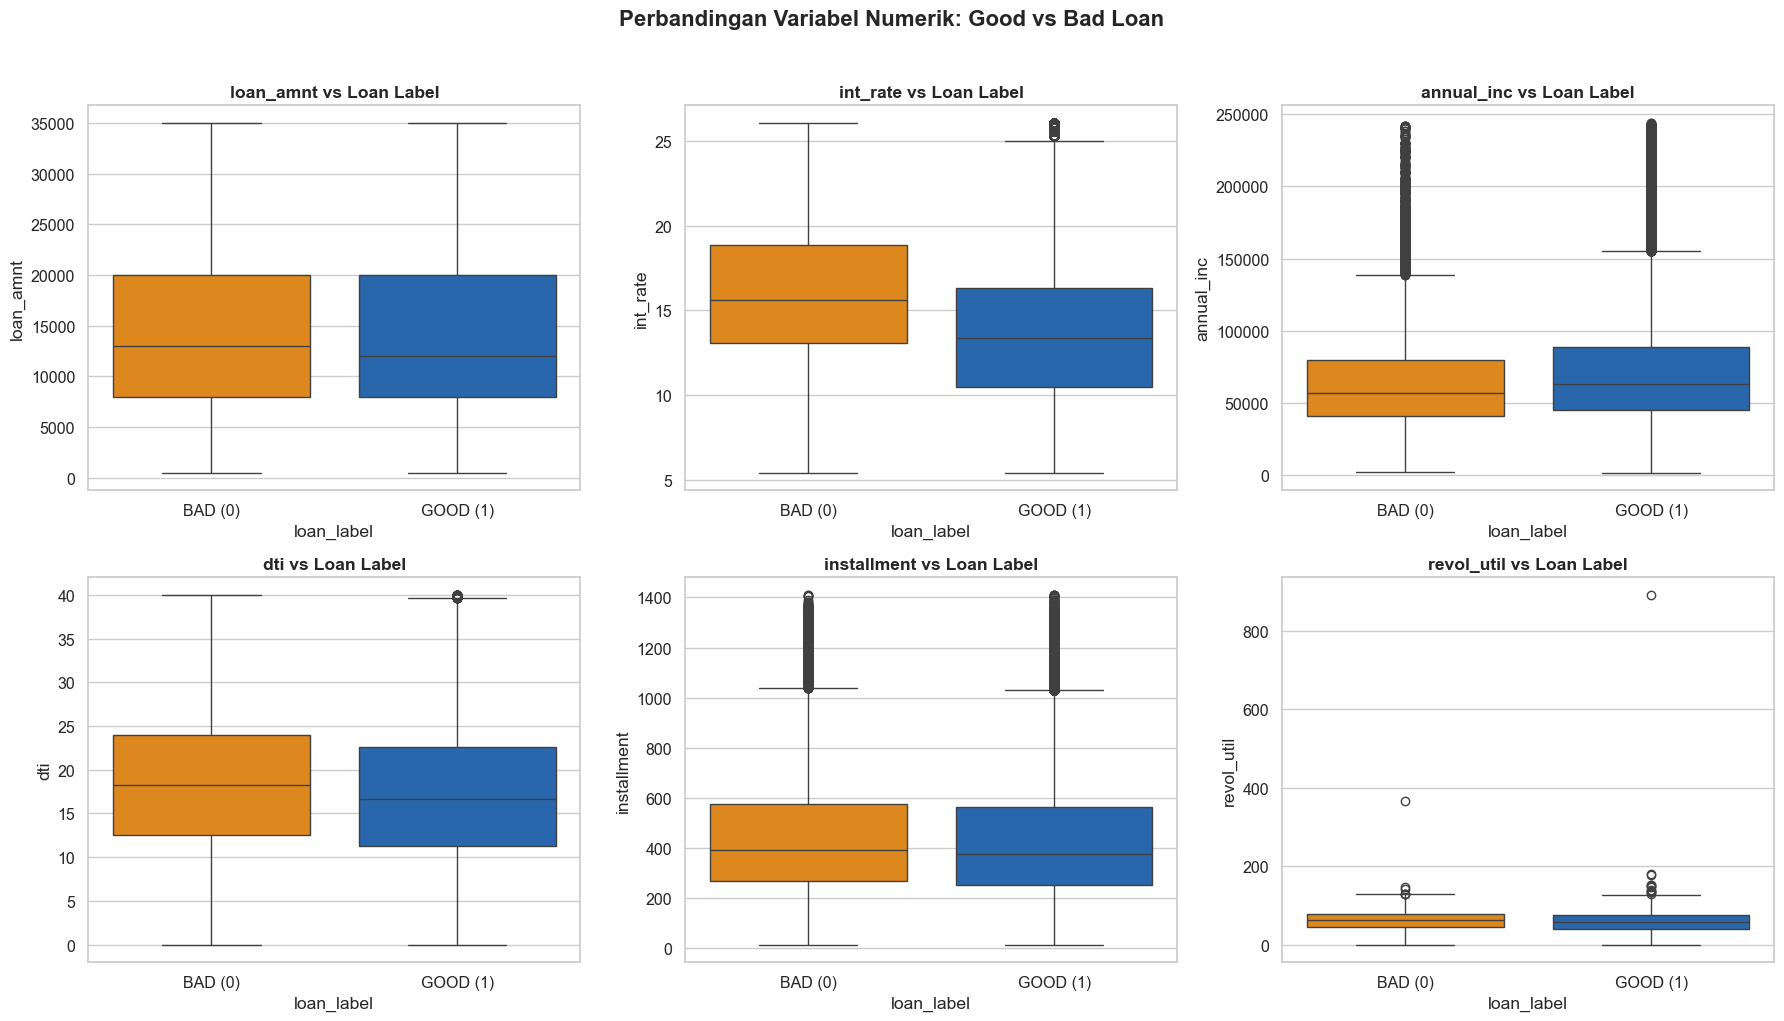

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_util']
available_plot = [c for c in plot_cols if c in df.columns]

for i, col in enumerate(available_plot):
    row, col_idx = i // 3, i % 3
    data = df[[col, 'loan_label']].dropna()
    if col == 'annual_inc':
        data = data[data[col] < data[col].quantile(0.99)]
    sns.boxplot(x='loan_label', y=col, data=data, ax=axes[row][col_idx],
                palette=['#FB8C00', '#1565C0'])
    axes[row][col_idx].set_title(f'{col} vs Loan Label', fontweight='bold')
    axes[row][col_idx].set_xticklabels(['BAD (0)', 'GOOD (1)'])
plt.suptitle('Perbandingan Variabel Numerik: Good vs Bad Loan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Analisis Variabel Kategorikal
Melihat distribusi variabel kategorikal terhadap label target.

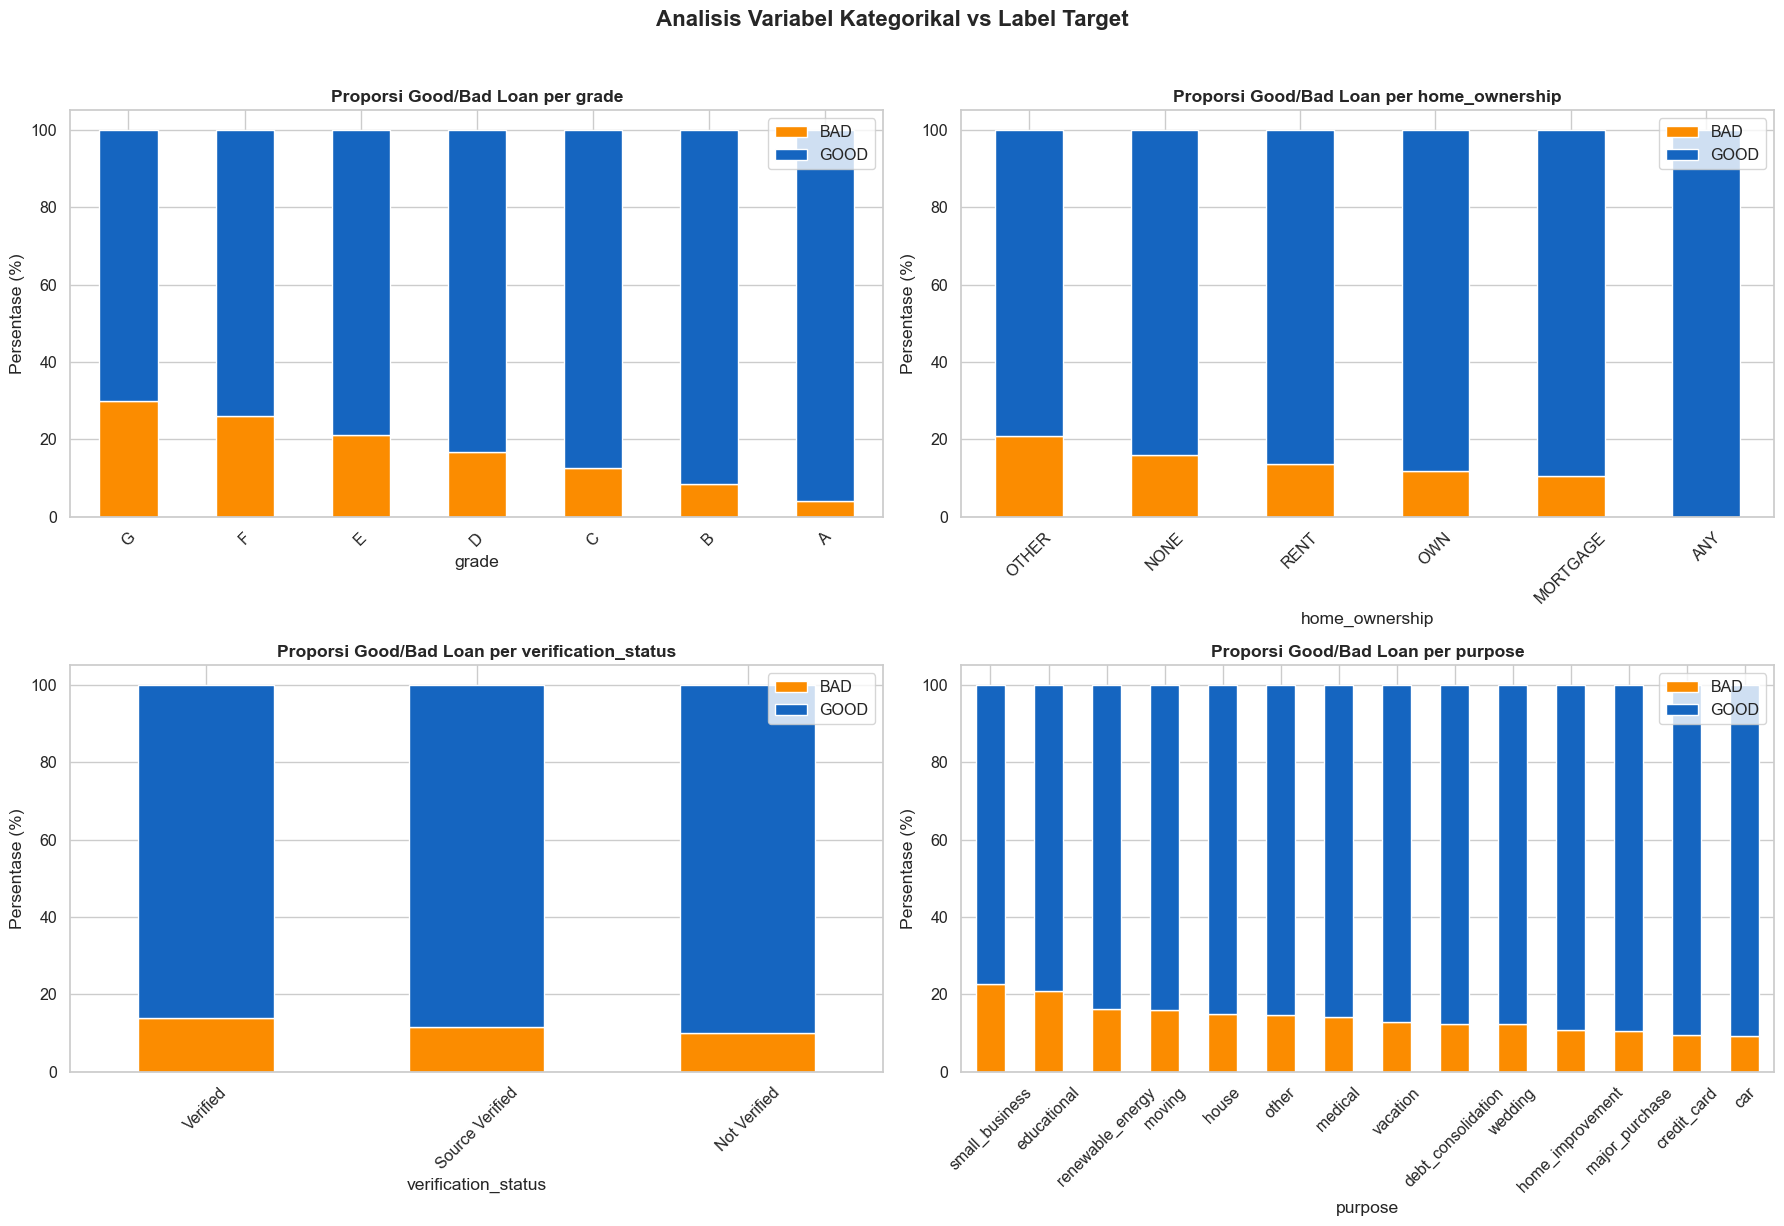

In [10]:
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_label'], normalize='index') * 100
    ct = ct.sort_values(0, ascending=False)
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#FB8C00', '#1565C0'], edgecolor='white')
    axes[i].set_title(f'Proporsi Good/Bad Loan per {col}', fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['BAD', 'GOOD'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Analisis Variabel Kategorikal vs Label Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Analisis Korelasi
Melihat korelasi antar variabel numerik menggunakan heatmap.

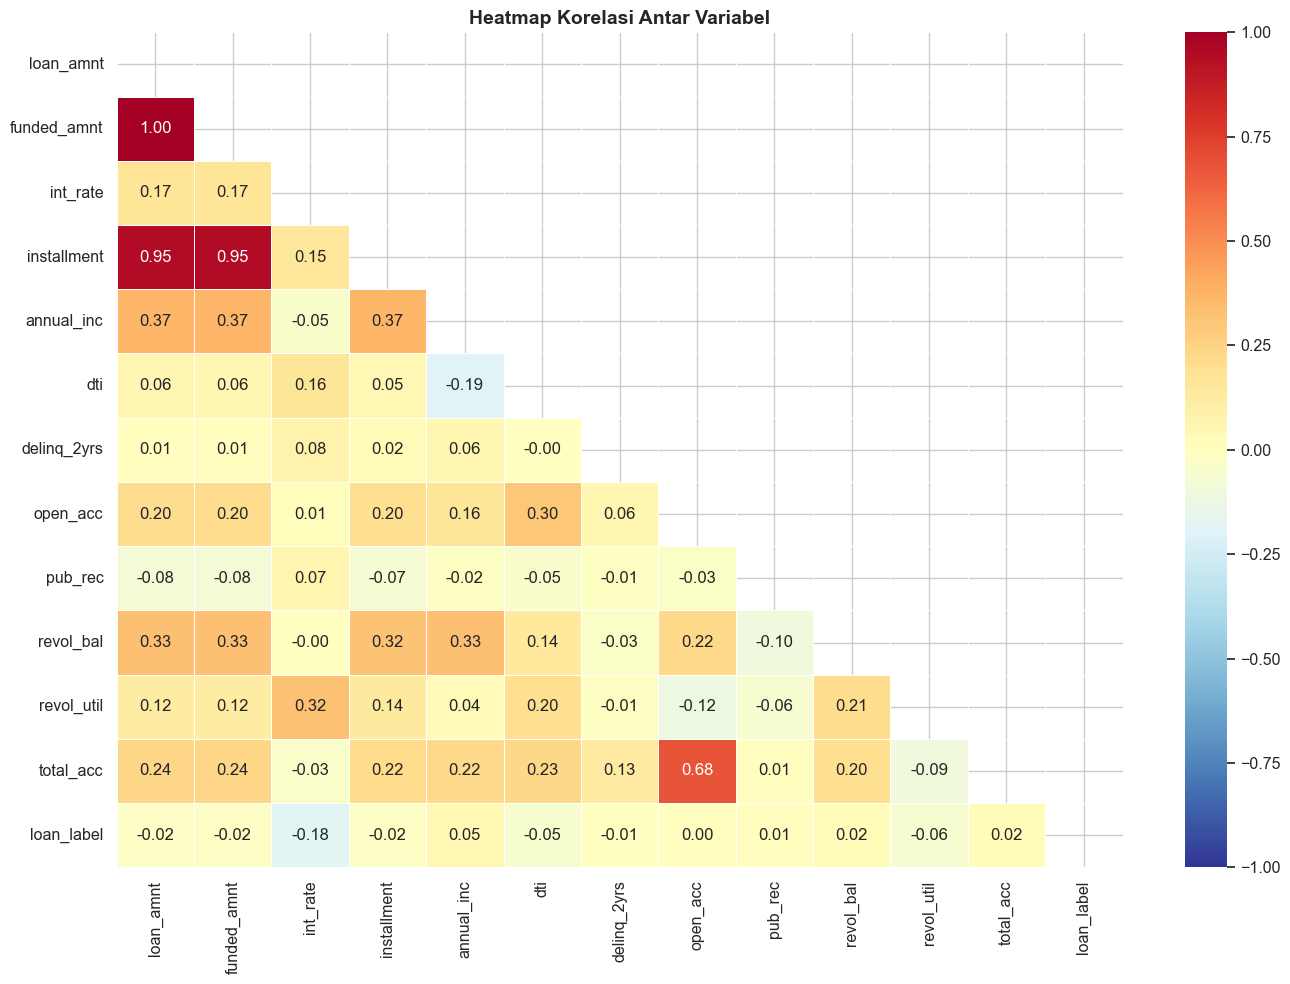

In [11]:
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal',
             'revol_util', 'total_acc', 'loan_label']
available_corr = [c for c in corr_cols if c in df.columns]

corr_matrix = df[available_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Preparation
### 5.1 Seleksi Fitur
Memilih fitur-fitur yang relevan untuk pemodelan dan menghapus kolom yang tidak diperlukan.

**Kolom yang dihapus:**
- Kolom identitas: `id`, `member_id`, `url`, `desc`, `title`, `emp_title`, `zip_code`
- Kolom status yang sudah digunakan sebagai label: `loan_status`
- Kolom post-loan (data yang hanya tersedia setelah pinjaman diberikan): `out_prncp`, `total_pymnt`, `recoveries`, dll.
- Kolom joint application (terlalu banyak missing): `annual_inc_joint`, `dti_joint`, dll.
- Kolom dengan data sangat sparse: `open_acc_6m`, `open_il_6m`, dll.

In [12]:
drop_cols = ['Unnamed: 0', 'id', 'member_id', 'url', 'desc', 'title', 'emp_title',
             'zip_code', 'loan_status', 'pymnt_plan', 'policy_code', 'application_type',
             'annual_inc_joint', 'dti_joint', 'verification_status_joint',
             'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
             'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
             'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
             'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
             'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
             'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
             'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d']

existing_drop = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=existing_drop)
print(f"Kolom sebelum seleksi: {df.shape[1]}")
print(f"Kolom setelah seleksi: {df_clean.shape[1]}")
print(f"\nKolom yang digunakan:\n{list(df_clean.columns)}")

Kolom sebelum seleksi: 76
Kolom setelah seleksi: 34

Kolom yang digunakan:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'loan_label']


### 5.2 Penanganan Missing Values
Mengisi atau menghapus missing values dengan teknik yang sesuai.

**Strategi:**
- Kolom dengan >50% missing values: **dihapus**
- Kolom numerik: diisi dengan **median** (lebih robust terhadap outlier)
- Kolom kategorikal: diisi dengan **modus** (nilai yang paling sering muncul)

In [13]:
missing_clean = df_clean.isnull().sum()
missing_clean = missing_clean[missing_clean > 0].sort_values(ascending=False)
print(f"Kolom dengan missing values: {len(missing_clean)}\n")
print(missing_clean)

Kolom dengan missing values: 17

mths_since_last_record         403647
mths_since_last_major_derog    367311
mths_since_last_delinq         250351
total_rev_hi_lim                70276
tot_cur_bal                     70276
tot_coll_amt                    70276
emp_length                      21008
revol_util                        340
collections_12_mths_ex_med        145
open_acc                           29
total_acc                          29
inq_last_6mths                     29
acc_now_delinq                     29
earliest_cr_line                   29
delinq_2yrs                        29
pub_rec                            29
annual_inc                          4
dtype: int64


In [14]:
# Hapus kolom dengan >50% missing
high_missing = [col for col in df_clean.columns if df_clean[col].isnull().sum() / len(df_clean) > 0.5]
print(f"Kolom dengan >50% missing (dihapus): {high_missing}")
df_clean = df_clean.drop(columns=high_missing)

# Isi missing values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"\nTotal missing values setelah penanganan: {df_clean.isnull().sum().sum()}")
print(f"Shape data: {df_clean.shape}")

Kolom dengan >50% missing (dihapus): ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog']

Total missing values setelah penanganan: 0
Shape data: (466285, 31)


### 5.3 Feature Engineering & Encoding
Melakukan encoding pada variabel kategorikal menggunakan Label Encoding agar dapat diproses oleh model machine learning.

In [15]:
cat_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
num_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'loan_label' in num_columns:
    num_columns.remove('loan_label')

print(f"Kolom Kategorikal ({len(cat_columns)}): {cat_columns}")
print(f"Kolom Numerik: {len(num_columns)} kolom")

Kolom Kategorikal (11): ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status']
Kolom Numerik: 19 kolom


In [16]:
le_dict = {}
for col in cat_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le
    print(f"  {col}: {len(le.classes_)} kategori di-encode")

print(f"\nShape data setelah encoding: {df_clean.shape}")

  term: 2 kategori di-encode
  grade: 7 kategori di-encode
  sub_grade: 35 kategori di-encode
  emp_length: 11 kategori di-encode
  home_ownership: 6 kategori di-encode
  verification_status: 3 kategori di-encode
  issue_d: 91 kategori di-encode
  purpose: 14 kategori di-encode
  addr_state: 50 kategori di-encode
  earliest_cr_line: 664 kategori di-encode
  initial_list_status: 2 kategori di-encode

Shape data setelah encoding: (466285, 31)


### 5.4 Penanganan Outlier
Mendeteksi dan menangani outlier pada variabel numerik menggunakan metode IQR (Interquartile Range).
Outlier di-*cap* (bukan dihapus) agar tidak kehilangan data.

In [17]:
outlier_cols = ['annual_inc', 'dti', 'revol_bal', 'revol_util', 'delinq_2yrs']
available_outlier = [c for c in outlier_cols if c in df_clean.columns]

print("Penanganan Outlier (IQR capping):\n")
for col in available_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {outliers_before:,} outlier di-cap (range: {lower:.2f} - {upper:.2f})")

print(f"\nOutlier handling selesai. Shape: {df_clean.shape}")

Penanganan Outlier (IQR capping):

  annual_inc: 19,899 outlier di-cap (range: -20929.50 - 154882.50)
  dti: 43 outlier di-cap (range: -5.77 - 39.91)
  revol_bal: 22,879 outlier di-cap (range: -14467.00 - 41213.00)
  revol_util: 19 outlier di-cap (range: -14.05 - 127.95)
  delinq_2yrs: 83,302 outlier di-cap (range: 0.00 - 0.00)

Outlier handling selesai. Shape: (466285, 31)


### 5.5 Split Data & Feature Scaling
Membagi data menjadi training set (80%) dan testing set (20%), lalu melakukan StandardScaler pada fitur numerik.
Stratified split digunakan agar proporsi label target tetap seimbang di kedua set.

In [18]:
X = df_clean.drop(columns=['loan_label'])
y = df_clean['loan_label']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Distribusi target:\n{y.value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

Shape X: (466285, 30)
Shape y: (466285,)
Distribusi target:
loan_label
1    410953
0     55332
Name: count, dtype: int64

Training set: 373,028 samples
Testing set:  93,257 samples


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Pastikan tidak ada inf atau NaN setelah scaling
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("Feature scaling selesai (StandardScaler)")
print(f"   Mean training (sample): {X_train_scaled[:, 0].mean():.6f}")
print(f"   Std training (sample):  {X_train_scaled[:, 0].std():.6f}")
print(f"   Ada NaN di train: {np.isnan(X_train_scaled).any()}")
print(f"   Ada Inf di train: {np.isinf(X_train_scaled).any()}")

Feature scaling selesai (StandardScaler)
   Mean training (sample): -0.000000
   Std training (sample):  1.000000
   Ada NaN di train: False
   Ada Inf di train: False


## 6. Data Modelling
### 6.1 Model 1: Logistic Regression
Logistic Regression adalah algoritma klasifikasi wajib yang digunakan dalam project ini.
Model ini cocok untuk klasifikasi biner dan memberikan probabilitas prediksi.

**Parameter:**
- `max_iter=1000`: Jumlah iterasi maksimum untuk konvergensi
- `solver='lbfgs'`: Optimizer yang efisien untuk dataset besar
- `class_weight='balanced'`: Menangani ketidakseimbangan kelas dengan memberikan bobot lebih pada kelas minoritas (BAD loan)
- `random_state=42`: Untuk reproduksibilitas

In [20]:
print("Melatih Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression selesai dilatih!")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=['BAD (0)', 'GOOD (1)']))

Melatih Logistic Regression...
Logistic Regression selesai dilatih!

Classification Report:

              precision    recall  f1-score   support

     BAD (0)       0.19      0.63      0.29     11066
    GOOD (1)       0.93      0.63      0.75     82191

    accuracy                           0.63     93257
   macro avg       0.56      0.63      0.52     93257
weighted avg       0.84      0.63      0.70     93257



### 6.2 Model 2: Random Forest Classifier
Random Forest dipilih sebagai algoritma kedua karena kemampuannya menangani data yang kompleks, non-linear, dan memberikan feature importance.

**Parameter:**
- `n_estimators=200`: Jumlah decision tree dalam ensemble
- `max_depth=20`: Kedalaman maksimum tree untuk mencegah overfitting
- `min_samples_split=10`: Jumlah minimum sampel untuk melakukan split
- `class_weight='balanced'`: Menangani imbalanced class
- `random_state=42`: Untuk reproduksibilitas

In [21]:
print("Melatih Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest selesai dilatih!")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=['BAD (0)', 'GOOD (1)']))

Melatih Random Forest Classifier...
Random Forest selesai dilatih!

Classification Report:

              precision    recall  f1-score   support

     BAD (0)       0.26      0.19      0.22     11066
    GOOD (1)       0.90      0.93      0.91     82191

    accuracy                           0.84     93257
   macro avg       0.58      0.56      0.57     93257
weighted avg       0.82      0.84      0.83     93257



## 7. Evaluation
### 7.1 Perbandingan Metrik Evaluasi
Membandingkan kinerja kedua model menggunakan berbagai metrik evaluasi:
- **Accuracy**: Proporsi prediksi yang benar
- **Precision**: Ketepatan prediksi positif (GOOD loan)
- **Recall**: Kemampuan mendeteksi semua data positif
- **F1-Score**: Harmonic mean dari Precision dan Recall
- **ROC-AUC**: Area Under the ROC Curve, mengukur kemampuan diskriminasi model

Perbandingan Metrik Evaluasi:

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6311     0.9275  0.6307    0.7508   0.6834
Random Forest          0.8396     0.8952  0.9265    0.9106   0.6855


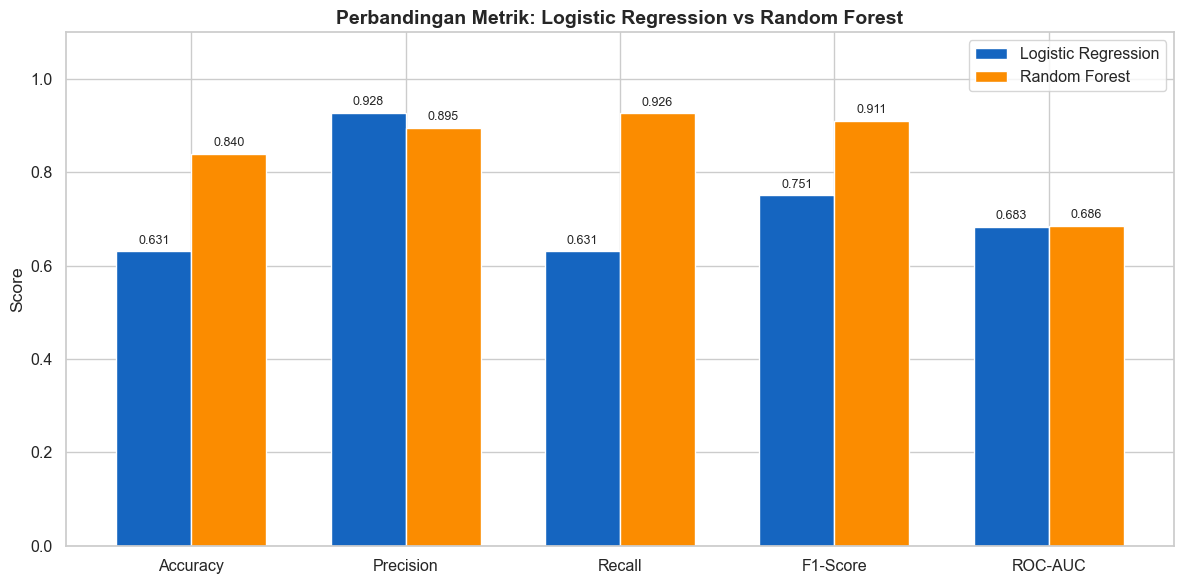

In [22]:
metrics = {}
for name, y_pred, y_prob in [('Logistic Regression', y_pred_lr, y_prob_lr),
                               ('Random Forest', y_pred_rf, y_prob_rf)]:
    metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

metrics_df = pd.DataFrame(metrics).T
print("Perbandingan Metrik Evaluasi:\n")
print(metrics_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df.columns))
width = 0.35
bars1 = ax.bar(x - width/2, metrics_df.iloc[0].values, width, label='Logistic Regression',
               color='#1565C0', edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_df.iloc[1].values, width, label='Random Forest',
               color='#FB8C00', edgecolor='white')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik: Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df.columns)
ax.legend()
ax.set_ylim(0, 1.1)
for b in [bars1, bars2]:
    for bar in b:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix
Visualisasi confusion matrix untuk kedua model. Confusion matrix menunjukkan jumlah True Positive, True Negative, False Positive, dan False Negative.

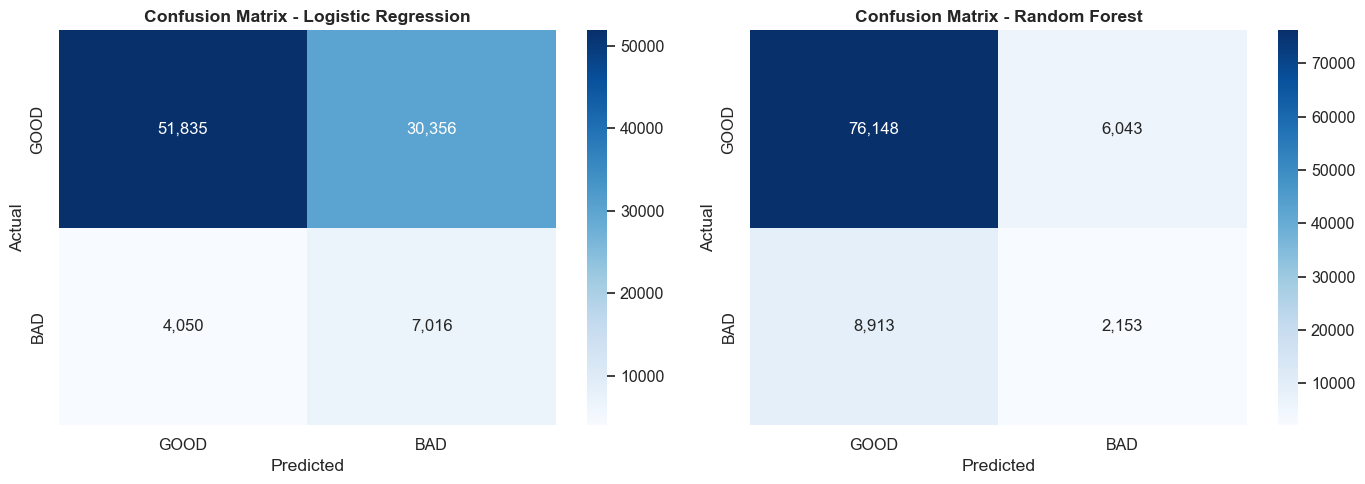

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, y_pred) in enumerate([('Logistic Regression', y_pred_lr),
                                      ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[i],
                xticklabels=['GOOD', 'BAD'], yticklabels=['GOOD', 'BAD'])
    axes[i].set_title(f'Confusion Matrix - {name}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 7.3 ROC Curve
Membandingkan kurva ROC (Receiver Operating Characteristic) kedua model.
Semakin besar area di bawah kurva (AUC), semakin baik kemampuan model dalam membedakan kelas positif dan negatif.

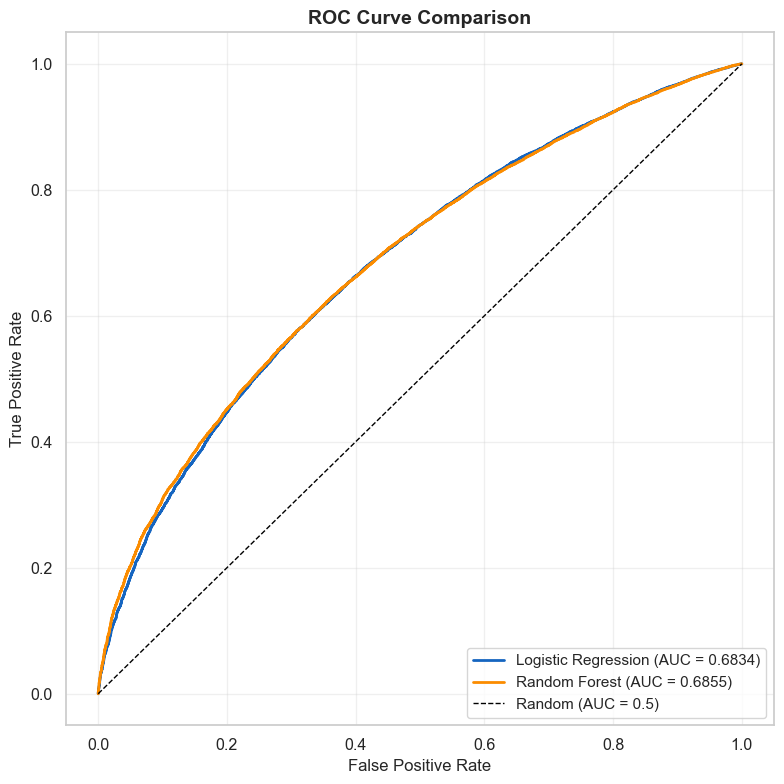

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, y_prob, color in [('Logistic Regression', y_prob_lr, '#1565C0'),
                              ('Random Forest', y_prob_rf, '#FB8C00')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Feature Importance (Random Forest)
Melihat fitur-fitur yang paling berpengaruh dalam prediksi model Random Forest.
Feature importance membantu mengidentifikasi variabel mana yang paling penting dalam menentukan good vs bad loan.

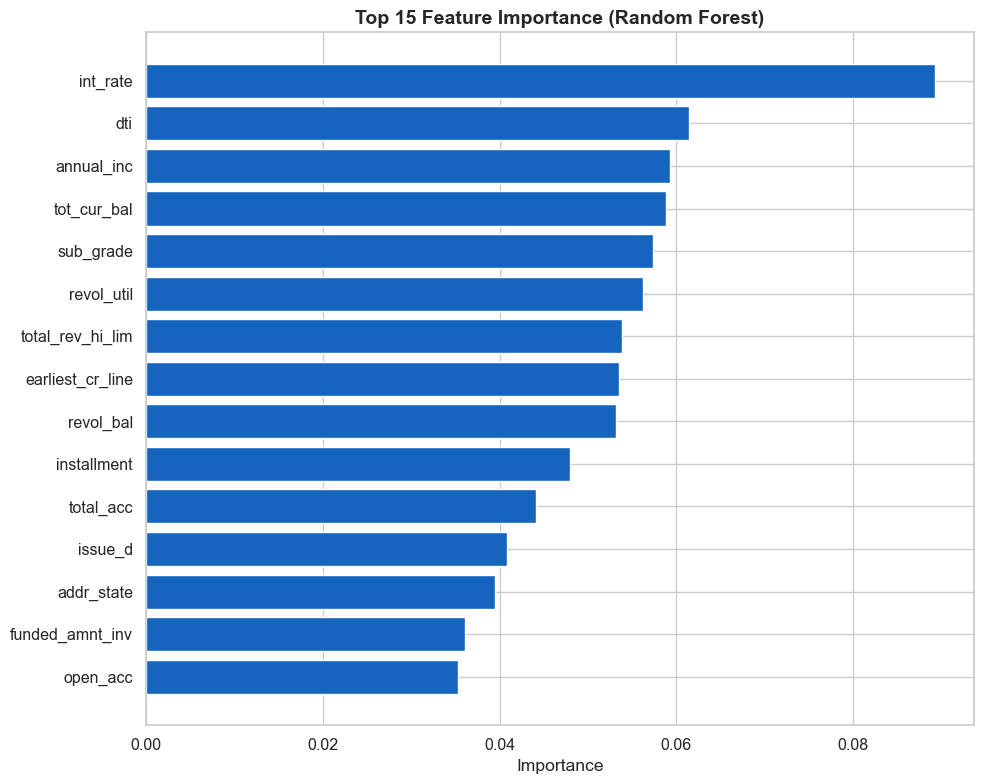

In [25]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#1565C0', edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Cross Validation
Melakukan 5-Fold Cross Validation untuk memvalidasi stabilitas dan konsistensi model.
Cross validation membagi data training menjadi 5 bagian (fold), melatih model pada 4 fold dan menguji pada 1 fold secara bergantian.

In [26]:
print("Melakukan 5-Fold Cross Validation...\n")

for name, model in [('Logistic Regression', lr_model), ('Random Forest', rf_model)]:
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    print(f"{name}:")
    print(f"   CV Scores: {cv_scores.round(4)}")
    print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})\n")

Melakukan 5-Fold Cross Validation...

Logistic Regression:
   CV Scores: [0.6283 0.631  0.6304 0.6278 0.6287]
   Mean CV Accuracy: 0.6293 (+/- 0.0025)

Random Forest:
   CV Scores: [0.8431 0.8442 0.8449 0.8428 0.8426]
   Mean CV Accuracy: 0.8435 (+/- 0.0017)



## 8. Kesimpulan

### Ringkasan Hasil:

1. **Data Understanding**: Dataset terdiri dari 466,285 data pinjaman dengan 75 kolom. Kolom `loan_status` digunakan sebagai dasar pembuatan label target (GOOD vs BAD loan).

2. **EDA**:
   - Distribusi data menunjukkan ketidakseimbangan antara GOOD dan BAD loan (~88% vs ~12%)
   - Variabel seperti `int_rate`, `grade`, dan `dti` menunjukkan perbedaan signifikan antara good dan bad loan
   - Korelasi antar variabel teridentifikasi (misalnya `loan_amnt` dan `installment` berkorelasi tinggi)

3. **Data Preparation**:
   - Missing values ditangani dengan median (numerik) dan modus (kategorikal)
   - Kolom dengan >50% missing values dihapus
   - Outlier ditangani dengan metode IQR capping
   - Variabel kategorikal di-encode menggunakan Label Encoding
   - Data dibagi 80:20 untuk training dan testing dengan stratified sampling
   - Feature scaling menggunakan StandardScaler

4. **Modelling & Evaluation**:
   - Dua model digunakan: **Logistic Regression** (wajib) dan **Random Forest**
   - Parameter `class_weight='balanced'` digunakan untuk menangani imbalanced data
   - Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC
   - Cross-validation 5-fold dilakukan untuk validasi stabilitas model

### Rekomendasi:
- Model dengan performa terbaik dapat dipilih berdasarkan kebutuhan bisnis
- Jika fokus pada minimalisir false negative (mendeteksi semua bad loan), prioritaskan **Recall**
- Jika fokus pada keseimbangan, gunakan **F1-Score** atau **ROC-AUC** sebagai metrik utama
- Untuk peningkatan lebih lanjut, bisa dicoba: SMOTE oversampling, feature engineering lebih lanjut, atau hyperparameter tuning dengan GridSearchCV